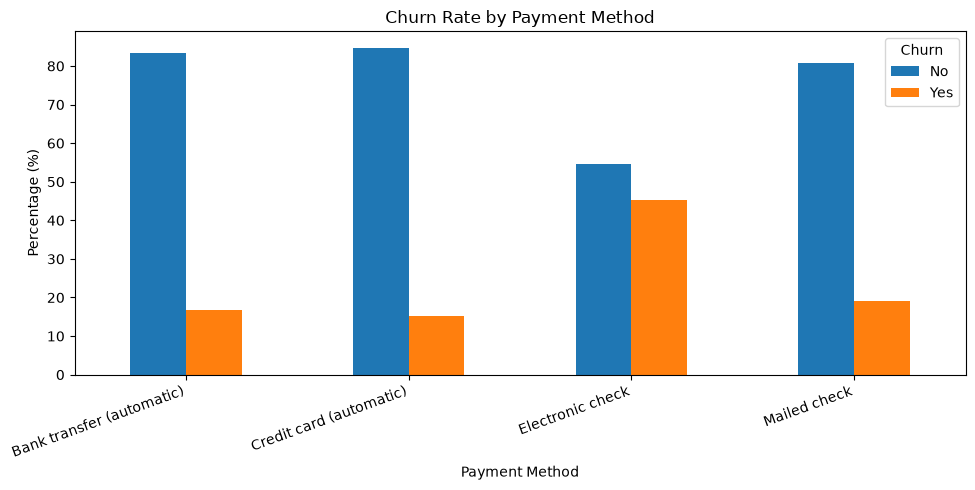

In [40]:
payment_churn.plot(kind="bar", figsize=(10, 5))
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")
plt.tight_layout()

plt.savefig("../visualizations/churn_by_payment_method.png", dpi=300, bbox_inches="tight")
plt.show()

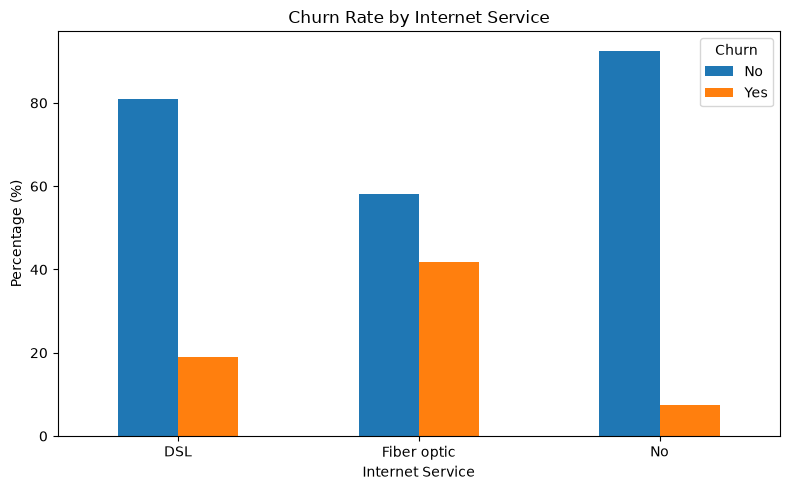

In [39]:
internet_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()

plt.savefig("../visualizations/churn_by_internet_service.png", dpi=300, bbox_inches="tight")
plt.show()

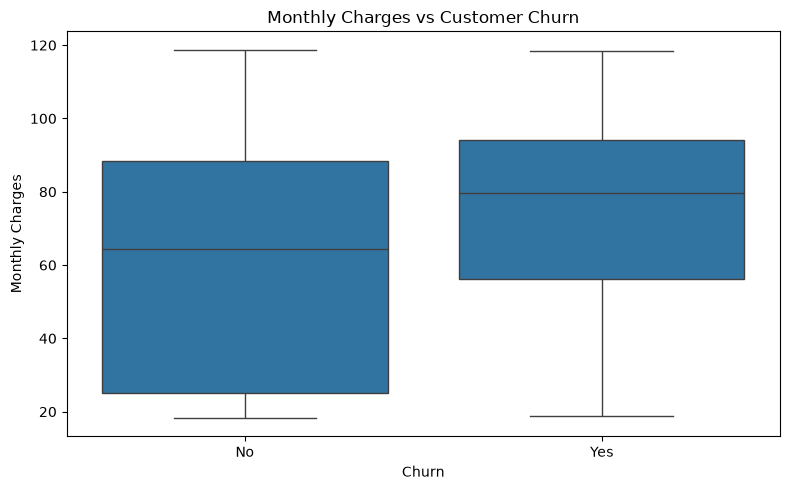

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()

plt.savefig("../visualizations/monthly_charges_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

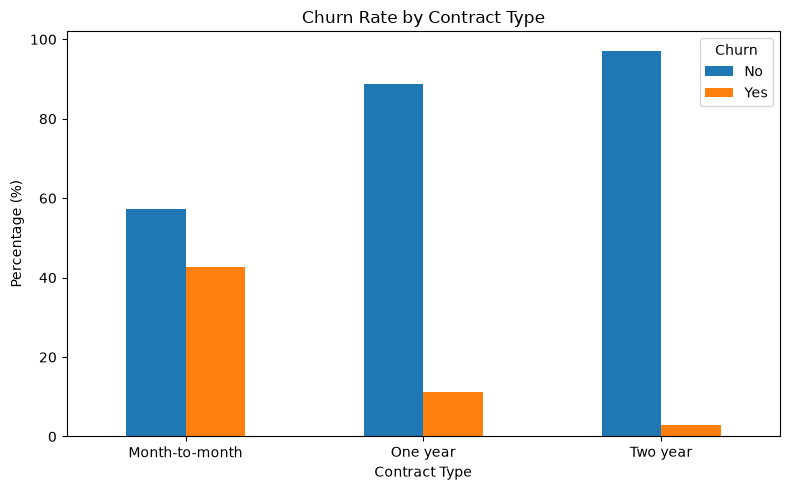

In [37]:
contract_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()

plt.savefig("../visualizations/churn_by_contract.png", dpi=300, bbox_inches="tight")
plt.show()

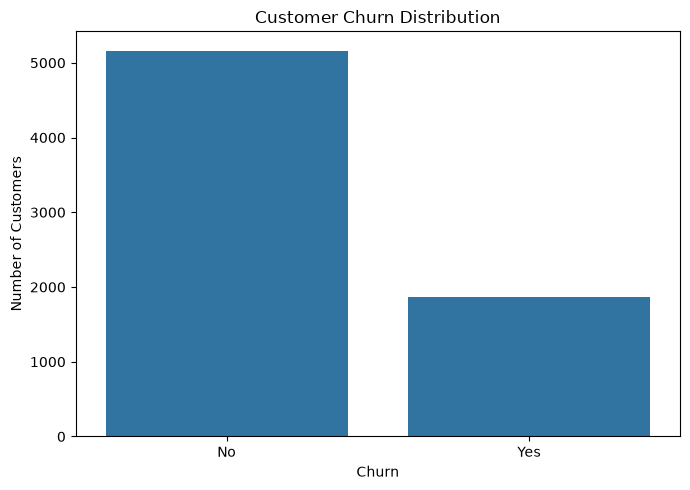

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig("../visualizations/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
query = """
SELECT 
    customerID,
    tenure,
    Contract,
    MonthlyCharges,
    InternetService,
    PaymentMethod,
    Churn
FROM customers
WHERE Churn = 'Yes'
  AND tenure <= 12
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

pd.read_sql_query(query, conn)

,customerID,tenure,Contract,MonthlyCharges,InternetService,PaymentMethod,Churn
0,1583-IHQZE,12,Month-to-month,112.95,Fiber optic,Mailed check,Yes
1,9851-KIELU,10,Month-to-month,110.10,Fiber optic,Electronic check,Yes
2,3992-YWPKO,6,Month-to-month,109.90,Fiber optic,Credit card (automatic),Yes
3,2027-FECZV,12,Month-to-month,106.70,Fiber optic,Electronic check,Yes
4,1400-MMYXY,3,Month-to-month,105.90,Fiber optic,Electronic check,Yes
5,3932-CMDTD,4,One year,105.65,Fiber optic,Electronic check,Yes
6,3389-YGYAI,8,Month-to-month,105.50,Fiber optic,Electronic check,Yes
7,5052-PNLOS,3,Month-to-month,105.35,Fiber optic,Bank transfer (automatic),Yes
8,4587-VVTOX,6,Month-to-month,105.30,Fiber optic,Electronic check,Yes
9,6496-SLWHQ,3,Month-to-month,105.00,Fiber optic,Electronic check,Yes


In [34]:
query = """
SELECT 
    Churn,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,avg_monthly_charges
0,No,61.31
1,Yes,74.44


In [33]:
query = """
SELECT 
    Contract,
    Churn,
    COUNT(*) AS customer_count
FROM customers
GROUP BY Contract, Churn
ORDER BY Contract, Churn;
"""

pd.read_sql_query(query, conn)

,Contract,Churn,customer_count
0,Month-to-month,No,2220
1,Month-to-month,Yes,1655
2,One year,No,1306
3,One year,Yes,166
4,Two year,No,1637
5,Two year,Yes,48


In [32]:
query = """
SELECT 
    Churn,
    COUNT(*) AS customer_count
FROM customers
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,customer_count
0,No,5163
1,Yes,1869


In [31]:
query = """
SELECT COUNT(*) AS total_customers
FROM customers;
"""

pd.read_sql_query(query, conn)

,total_customers
0,7032


In [30]:
import sqlite3

conn = sqlite3.connect("../sql/customer_churn.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully!")

Database created successfully!


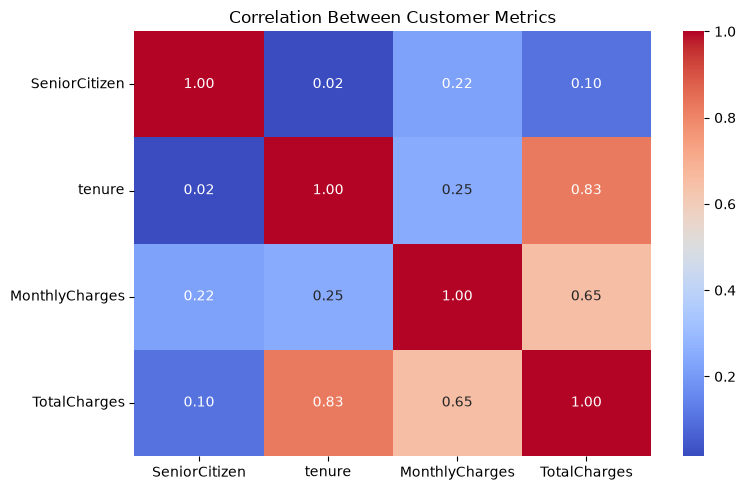

In [29]:
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(8, 5))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Customer Metrics")
plt.tight_layout()
plt.show()

In [28]:
total_customers = len(df)
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = churned_customers / total_customers * 100

avg_monthly_charges_churned = df.loc[
    df["Churn"] == "Yes", "MonthlyCharges"
].mean()

avg_monthly_charges_stayed = df.loc[
    df["Churn"] == "No", "MonthlyCharges"
].mean()

avg_tenure_churned = df.loc[
    df["Churn"] == "Yes", "tenure"
].mean()

avg_tenure_stayed = df.loc[
    df["Churn"] == "No", "tenure"
].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Overall Churn Rate:", round(churn_rate, 2), "%")
print("Avg Monthly Charges - Churned:", round(avg_monthly_charges_churned, 2))
print("Avg Monthly Charges - Stayed:", round(avg_monthly_charges_stayed, 2))
print("Avg Tenure - Churned:", round(avg_tenure_churned, 2), "months")
print("Avg Tenure - Stayed:", round(avg_tenure_stayed, 2), "months")

Total Customers: 7032
Churned Customers: 1869
Overall Churn Rate: 26.58 %
Avg Monthly Charges - Churned: 74.44
Avg Monthly Charges - Stayed: 61.31
Avg Tenure - Churned: 17.98 months
Avg Tenure - Stayed: 37.65 months


In [27]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print("Partner vs Churn:")
display(partner_churn.round(2))

print("\nDependents vs Churn:")
display(dependents_churn.round(2))

Partner vs Churn:


Churn,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72



Dependents vs Churn:


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


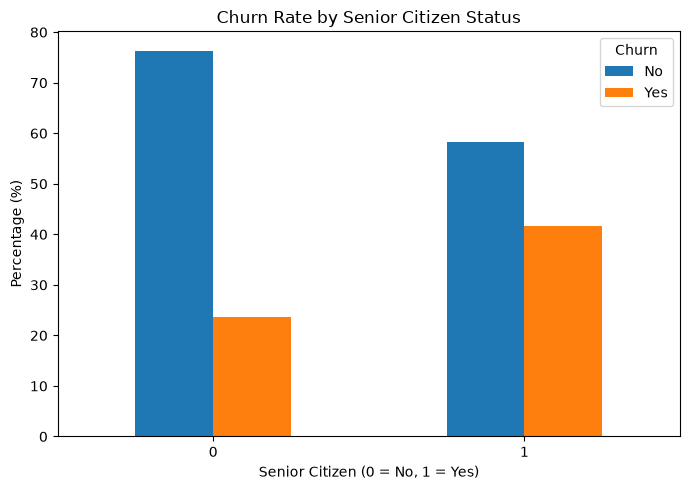

In [26]:
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [25]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


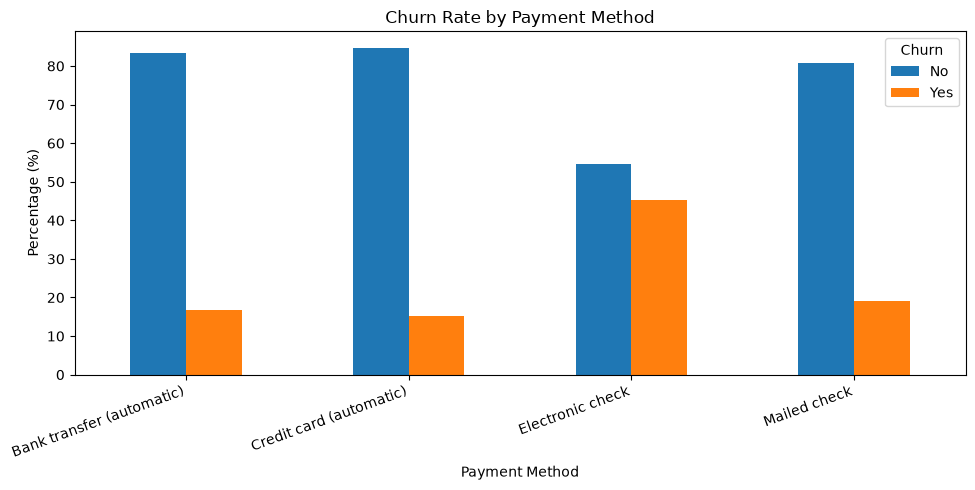

In [24]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [23]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


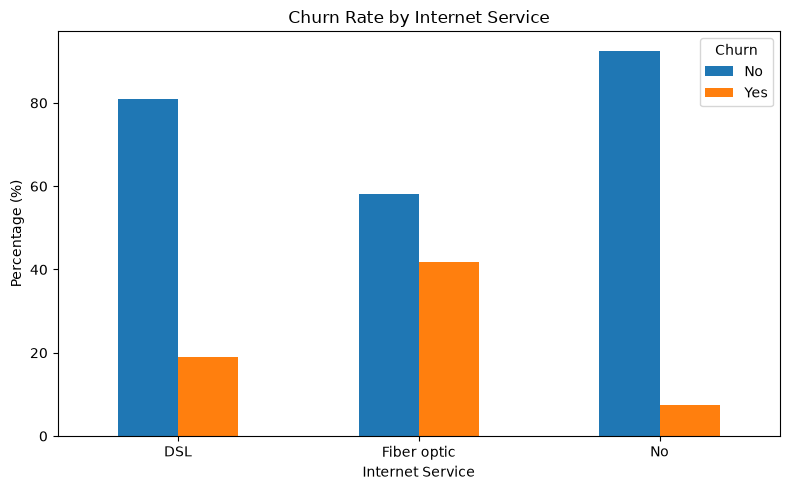

In [22]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [21]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


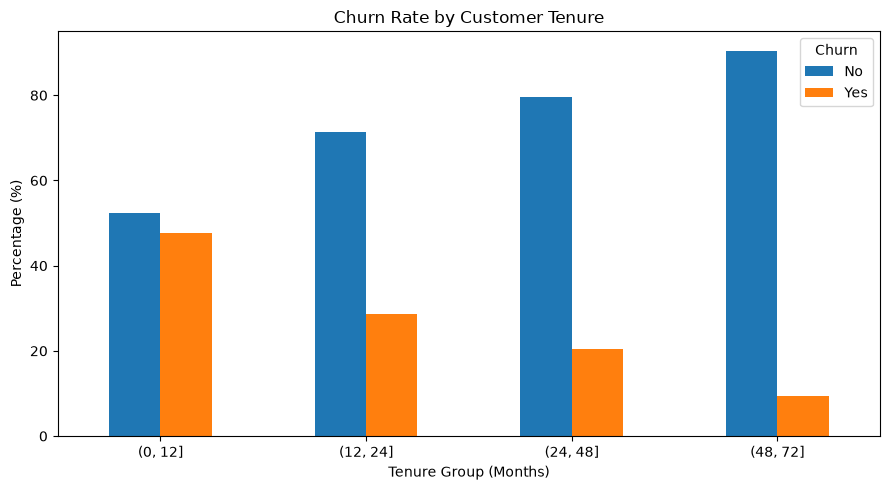

In [20]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [19]:
tenure_churn = pd.crosstab(
    pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72]),
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
tenure,,
"(0, 12]",52.32,47.68
"(12, 24]",71.29,28.71
"(24, 48]",79.61,20.39
"(48, 72]",90.49,9.51


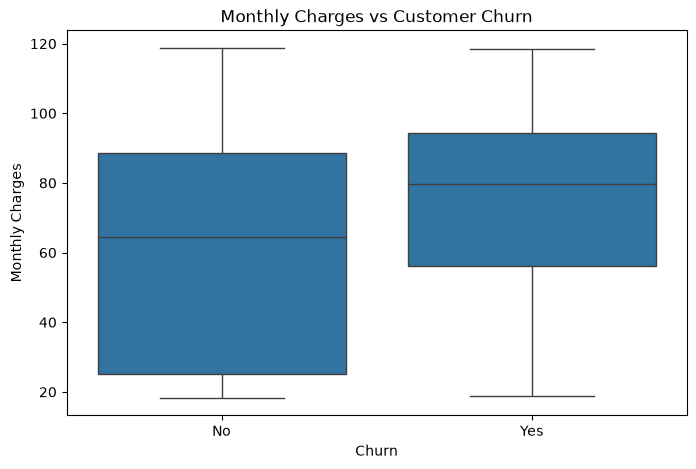

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

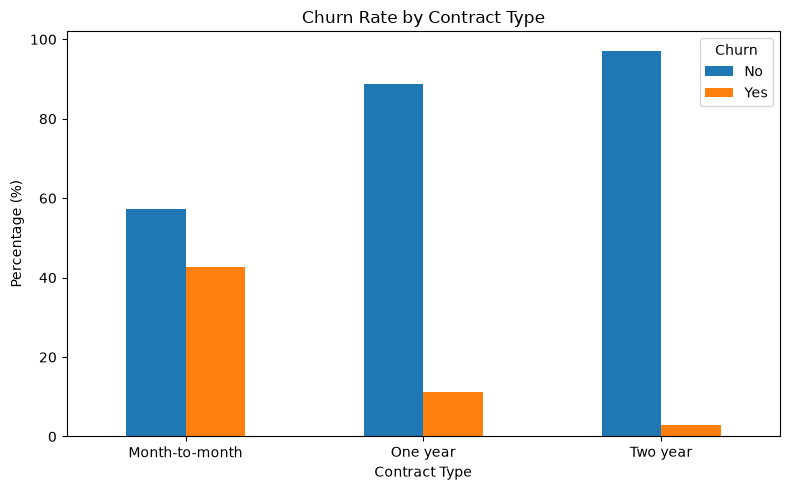

In [17]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [16]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


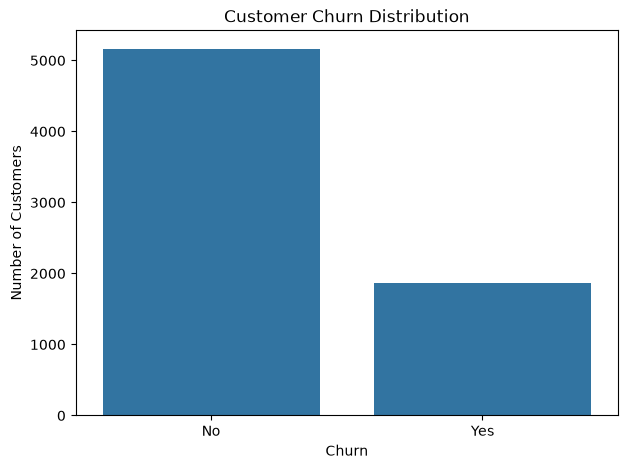

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

print("\nChurn Percentage:")
print((churn_counts / len(df) * 100).round(2))

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: count, dtype: float64


In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df = df.dropna(subset=["TotalCharges"])

print("Dataset Shape after cleaning:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Dataset Shape after cleaning: (7032, 21)
Missing Values: 0


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 11


In [9]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [6]:
df = pd.read_csv("../data/Telco-Customer-Churn .csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
import os

print(os.getcwd())
print(os.listdir("../data"))

/Users/richa/Documents/Data Analyst/Customer Churn Analysis/notebooks
['Telco-Customer-Churn .csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [2]:
%pip install pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 3.6 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 2.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.3 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 2.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]8/10 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
